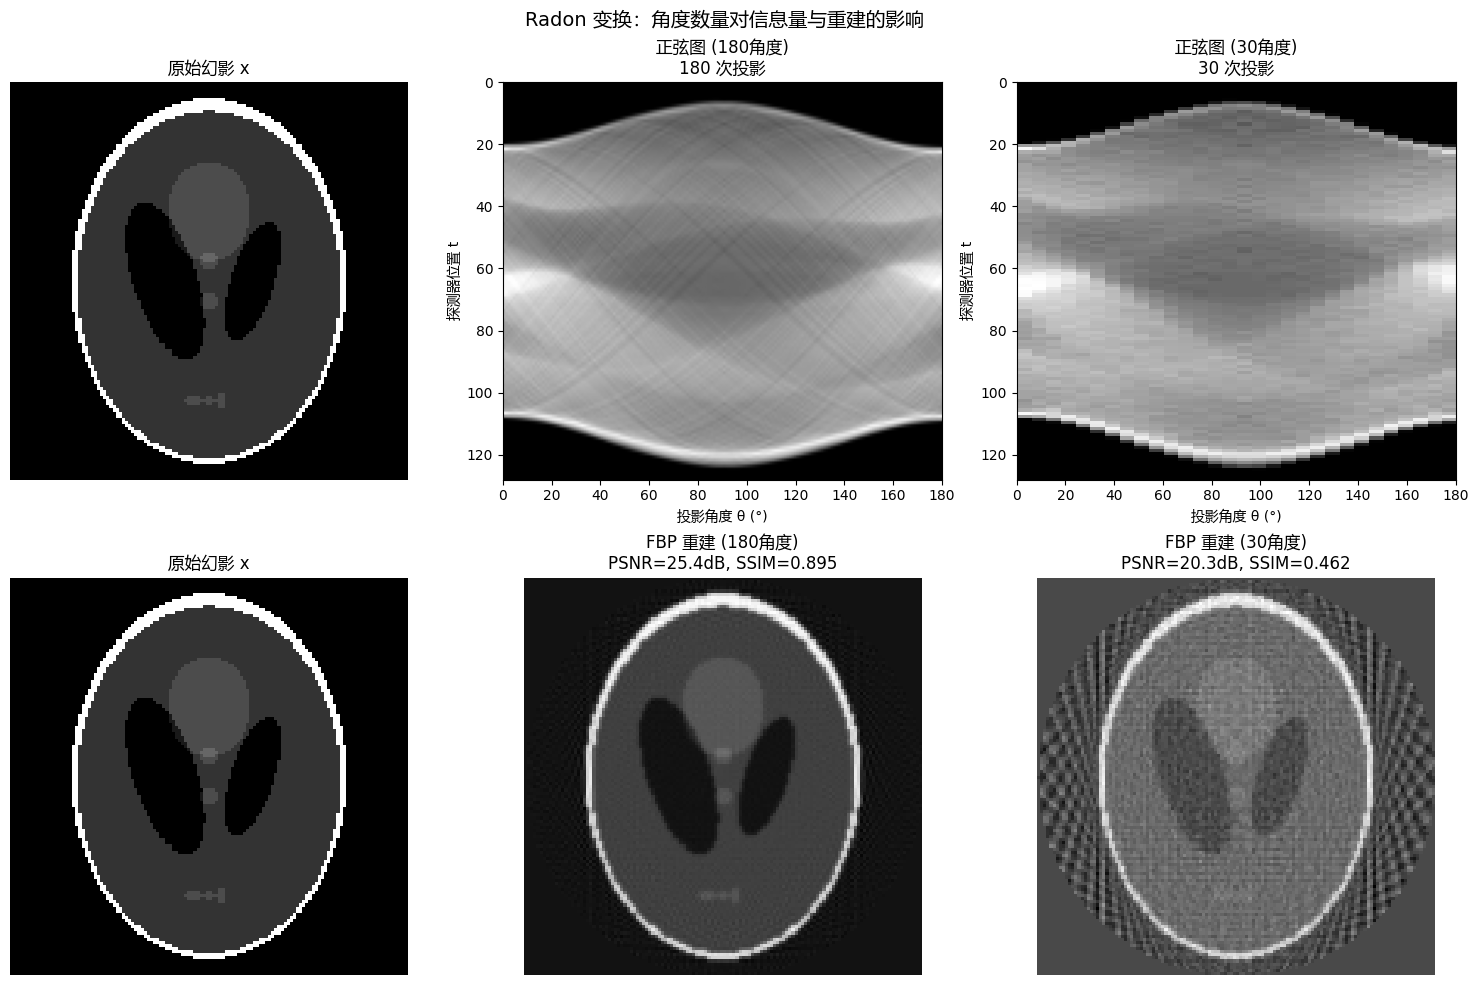

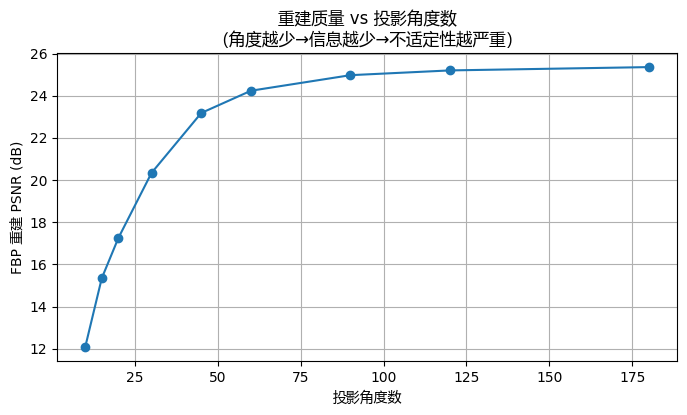

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 准备幻影图像 ----
n = 128
phantom = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=False)
phantom = phantom / phantom.max()

# ---- 2. 完整角度 vs 稀疏角度的 Radon 变换 ----
theta_full = np.linspace(0, 180, 180, endpoint=False)
theta_sparse = np.linspace(0, 180, 30, endpoint=False)

sinogram_full = radon(phantom, theta=theta_full, circle=True)
sinogram_sparse = radon(phantom, theta=theta_sparse, circle=True)

# ---- 3. FBP 重建 ----
recon_full = iradon(sinogram_full, theta=theta_full, circle=True, filter_name='ramp')
recon_sparse = iradon(sinogram_sparse, theta=theta_sparse, circle=True, filter_name='ramp')

# ---- 4. 质量评估 ----
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_full = peak_signal_noise_ratio(phantom, recon_full)
psnr_sparse = peak_signal_noise_ratio(phantom, recon_sparse)
ssim_full = structural_similarity(phantom, recon_full, data_range=1.0)
ssim_sparse = structural_similarity(phantom, recon_sparse, data_range=1.0)

# ---- 5. 可视化 ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(phantom, cmap='gray')
axes[0, 0].set_title('原始幻影 x')
axes[0, 0].axis('off')

axes[0, 1].imshow(sinogram_full, cmap='gray', aspect='auto',
                   extent=[0, 180, sinogram_full.shape[0], 0])
axes[0, 1].set_title(f'正弦图 (180角度)\n{sinogram_full.shape[1]} 次投影')
axes[0, 1].set_xlabel('投影角度 θ (°)')
axes[0, 1].set_ylabel('探测器位置 t')

axes[0, 2].imshow(sinogram_sparse, cmap='gray', aspect='auto',
                   extent=[0, 180, sinogram_sparse.shape[0], 0])
axes[0, 2].set_title(f'正弦图 (30角度)\n{sinogram_sparse.shape[1]} 次投影')
axes[0, 2].set_xlabel('投影角度 θ (°)')
axes[0, 2].set_ylabel('探测器位置 t')

axes[1, 0].imshow(phantom, cmap='gray')
axes[1, 0].set_title('原始幻影 x')
axes[1, 0].axis('off')

axes[1, 1].imshow(recon_full, cmap='gray')
axes[1, 1].set_title(f'FBP 重建 (180角度)\nPSNR={psnr_full:.1f}dB, SSIM={ssim_full:.3f}')
axes[1, 1].axis('off')

axes[1, 2].imshow(recon_sparse, cmap='gray')
axes[1, 2].set_title(f'FBP 重建 (30角度)\nPSNR={psnr_sparse:.1f}dB, SSIM={ssim_sparse:.3f}')
axes[1, 2].axis('off')

plt.suptitle('Radon 变换：角度数量对信息量与重建的影响', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_4_Radon变换.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 6. 角度数量 vs 重建质量曲线 ----
n_angles_list = [10, 15, 20, 30, 45, 60, 90, 120, 180]
psnr_curve = []
for na in n_angles_list:
    theta = np.linspace(0, 180, na, endpoint=False)
    sino = radon(phantom, theta=theta, circle=True)
    recon = iradon(sino, theta=theta, circle=True, filter_name='ramp')
    psnr_curve.append(peak_signal_noise_ratio(phantom, recon))

plt.figure(figsize=(8, 4))
plt.plot(n_angles_list, psnr_curve, 'o-')
plt.xlabel('投影角度数')
plt.ylabel('FBP 重建 PSNR (dB)')
plt.title('重建质量 vs 投影角度数\n（角度越少→信息越少→不适定性越严重）')
plt.grid(True)
plt.savefig('实验1_4_角度vs质量.png', dpi=150, bbox_inches='tight')
plt.show()